<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/heatTransfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heat transfer with NeqSim

**Audience.** Process, mechanical, and energy engineers who know basic thermodynamics and want a reproducible bridge from real-fluid properties to heat-exchanger screening.

**Prerequisites.** Familiarity with steady-state energy balances, SI units, and elementary Python is useful. No local files or proprietary data are required.

## Learning objectives

After completing the notebook, you can:

1. calculate temperature-dependent gas properties with NeqSim;
2. simulate a two-stream heat exchanger with the current NeqSim process API;
3. verify energy conservation, effectiveness, LMTD, and entropy generation;
4. translate conductances into a screening surface area;
5. study UA, flow-rate, and fouling sensitivities without hidden state; and
6. recognize where preliminary thermal screening must give way to detailed design.

## Engineering context, scope, and assumptions

The example cools a pressurized natural-gas stream from a compressor discharge by exchanging heat with a colder stream of the same nominal composition. This avoids introducing a utility-fluid model and keeps attention on real-gas caloric and transport properties.

Assumptions are steady state, adiabatic exchanger boundary, negligible kinetic and potential energy changes, no pressure drop, no heat loss, and single-phase gas on both sides. Temperatures are reported in degrees Celsius, pressure in bara, mass flow in kg/h, duty in kW, conductance UA in W/K, heat-transfer coefficient in W/(m² K), and area in m².

The calculation is a screening study, not a mechanical design or certification. A real design also needs pressure drop, vibration, nozzle loads, thermal stresses, materials, corrosion allowance, relief cases, and applicable codes.

In [1]:
import platform
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    NEQSIM_VERSION = version("neqsim")
except PackageNotFoundError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )
    NEQSIM_VERSION = version("neqsim")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim.process import clearProcess, heatExchanger, runProcess, stream
from neqsim.thermo import TPflash, fluid

PYTHON_VERSION = platform.python_version()
JAVA_VERSION = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]

print(f"NeqSim: {NEQSIM_VERSION}")
print(f"Python: {PYTHON_VERSION}")
print(f"Java: {JAVA_VERSION}")

NeqSim: 3.16.0
Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21


## Governing balances and NeqSim workflow

For an adiabatic two-stream exchanger, the steady-state energy balance is

$$
\dot H_{h,out}-\dot H_{h,in}+\dot H_{c,out}-\dot H_{c,in}=0
$$

where $\dot H$ is enthalpy flow in W; subscripts $h$ and $c$ identify the hot and cold sides. NeqSim evaluates these enthalpy flows from the equation of state instead of assuming a constant heat capacity.

The solver workflow is: define each thermodynamic system, flash it at its inlet state, wrap it in a `Stream`, connect both streams to a `HeatExchanger`, specify UA, and run the process. The resulting outlet streams remain composable with other NeqSim unit operations.

In [2]:
GAS_COMPOSITION = {
    "methane": 0.88,
    "ethane": 0.06,
    "propane": 0.03,
    "CO2": 0.02,
    "nitrogen": 0.01,
}


def make_gas_system(temperature_c, pressure_bara):
    gas = fluid("srk")
    for component, mole_fraction in GAS_COMPOSITION.items():
        gas.addComponent(component, mole_fraction)

    gas.setMixingRule("classic")
    gas.setTemperature(float(temperature_c), "C")
    gas.setPressure(float(pressure_bara), "bara")
    TPflash(gas)
    gas.initProperties()
    return gas


def make_gas_stream(name, temperature_c, pressure_bara, flow_kg_h):
    gas_stream = stream(
        name,
        make_gas_system(temperature_c, pressure_bara),
    )
    gas_stream.setTemperature(float(temperature_c), "C")
    gas_stream.setPressure(float(pressure_bara), "bara")
    gas_stream.setFlowRate(float(flow_kg_h), "kg/hr")
    return gas_stream


def run_exchanger_case(ua_w_k, cold_flow_kg_h=12_000.0):
    clearProcess()
    hot_stream = make_gas_stream("hot gas", 120.0, 60.0, 10_000.0)
    cold_stream = make_gas_stream(
        "cold gas",
        20.0,
        55.0,
        cold_flow_kg_h,
    )

    exchanger = heatExchanger(
        "gas-gas heat exchanger",
        hot_stream,
        cold_stream,
    )
    exchanger.setUAvalue(float(ua_w_k))
    runProcess()

    hot_outlet = exchanger.getOutStream(0)
    cold_outlet = exchanger.getOutStream(1)
    return {
        "ua_w_k": float(ua_w_k),
        "cold_flow_kg_h": float(cold_flow_kg_h),
        "hot_inlet_c": hot_stream.getTemperature("C"),
        "cold_inlet_c": cold_stream.getTemperature("C"),
        "hot_outlet_c": hot_outlet.getTemperature("C"),
        "cold_outlet_c": cold_outlet.getTemperature("C"),
        "hot_flow_in_kg_h": hot_stream.getFlowRate("kg/hr"),
        "hot_flow_out_kg_h": hot_outlet.getFlowRate("kg/hr"),
        "cold_flow_in_kg_h": cold_stream.getFlowRate("kg/hr"),
        "cold_flow_out_kg_h": cold_outlet.getFlowRate("kg/hr"),
        "hot_h_in_w": hot_stream.getFluid().getEnthalpy(),
        "hot_h_out_w": hot_outlet.getFluid().getEnthalpy(),
        "cold_h_in_w": cold_stream.getFluid().getEnthalpy(),
        "cold_h_out_w": cold_outlet.getFluid().getEnthalpy(),
        "duty_w": exchanger.getDuty(),
        "effectiveness": exchanger.getThermalEffectiveness(),
        "entropy_generation_w_k": exchanger.getEntropyProduction("J/K"),
        "hot_phases": hot_outlet.getFluid().getNumberOfPhases(),
        "cold_phases": cold_outlet.getFluid().getNumberOfPhases(),
    }

## Base fluids and model choice

The Soave–Redlich–Kwong (SRK) equation of state with the classic mixing rule is a practical baseline for a hydrocarbon-rich gas. The composition is synthetic but realistic enough to show non-ideal density and heat capacity. It is not tuned to laboratory data.

Each property state is freshly created and flashed. This prevents a sensitivity study from inheriting a previous state and makes every row independently reproducible.

In [3]:
inlet_states = [
    ("Hot inlet", 120.0, 60.0),
    ("Cold inlet", 20.0, 55.0),
]
property_rows = []

for label, temperature_c, pressure_bara in inlet_states:
    gas = make_gas_system(temperature_c, pressure_bara)
    phase = gas.getPhase("gas")
    property_rows.append(
        {
            "State": label,
            "Temperature (°C)": temperature_c,
            "Pressure (bara)": pressure_bara,
            "Density (kg/m³)": phase.getDensity("kg/m3"),
            "Cp (J/(kg K))": phase.getCp("J/kgK"),
            "Viscosity (Pa s)": phase.getViscosity("kg/msec"),
            "Conductivity (W/(m K))": phase.getThermalConductivity("W/mK"),
        }
    )

inlet_property_table = pd.DataFrame(property_rows)
print(inlet_property_table.to_string(index=False, float_format=lambda value: f"{value:.6g}"))

     State  Temperature (°C)  Pressure (bara)  Density (kg/m³)  Cp (J/(kg K))  Viscosity (Pa s)  Conductivity (W/(m K))
 Hot inlet               120               60          34.8861        2558.76       1.52028e-05               0.0504704
Cold inlet                20               55          47.4195        2534.16       1.24945e-05               0.0380155


## Native two-stream exchanger

The base case uses UA = 25,000 W/K. NeqSim performs coupled enthalpy flashes on the two outlet streams. A positive temperature approach is required at both ends; temperature crossing would invalidate this simple steady counter-current interpretation.

In [4]:
BASE_UA_W_K = 25_000.0
base_case = run_exchanger_case(BASE_UA_W_K)

base_result_table = pd.DataFrame(
    [
        {
            "Quantity": "Hot outlet temperature",
            "Value": base_case["hot_outlet_c"],
            "Unit": "°C",
        },
        {
            "Quantity": "Cold outlet temperature",
            "Value": base_case["cold_outlet_c"],
            "Unit": "°C",
        },
        {
            "Quantity": "Transferred duty",
            "Value": abs(base_case["duty_w"]) / 1_000.0,
            "Unit": "kW",
        },
        {
            "Quantity": "Thermal effectiveness",
            "Value": base_case["effectiveness"],
            "Unit": "fraction",
        },
        {
            "Quantity": "Entropy generation",
            "Value": base_case["entropy_generation_w_k"],
            "Unit": "W/K",
        },
    ]
)

print(base_result_table.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

               Quantity      Value     Unit
 Hot outlet temperature  37.114851       °C
Cold outlet temperature  89.997135       °C
       Transferred duty 579.935857       kW
  Thermal effectiveness   0.826599 fraction
     Entropy generation 621.496437      W/K


## Conservation and phase checks

The exchanger cannot create or destroy material. It also cannot create energy inside the stated adiabatic boundary. The balance residual is evaluated directly from the four NeqSim enthalpy flows, independently of the reported exchanger duty.

Single-phase outlet checks matter because latent heat or condensation would change the interpretation of effective heat capacities and the analytical comparisons that follow.

In [5]:
hot_enthalpy_change_w = base_case["hot_h_out_w"] - base_case["hot_h_in_w"]
cold_enthalpy_change_w = base_case["cold_h_out_w"] - base_case["cold_h_in_w"]
energy_residual_w = hot_enthalpy_change_w + cold_enthalpy_change_w

hot_mass_residual_kg_h = (
    base_case["hot_flow_out_kg_h"] - base_case["hot_flow_in_kg_h"]
)
cold_mass_residual_kg_h = (
    base_case["cold_flow_out_kg_h"] - base_case["cold_flow_in_kg_h"]
)

balance_table = pd.DataFrame(
    [
        {"Check": "Hot-side enthalpy change", "Value": hot_enthalpy_change_w, "Unit": "W"},
        {
            "Check": "Cold-side enthalpy change",
            "Value": cold_enthalpy_change_w,
            "Unit": "W",
        },
        {"Check": "Overall energy residual", "Value": energy_residual_w, "Unit": "W"},
        {"Check": "Hot-side mass residual", "Value": hot_mass_residual_kg_h, "Unit": "kg/h"},
        {
            "Check": "Cold-side mass residual",
            "Value": cold_mass_residual_kg_h,
            "Unit": "kg/h",
        },
    ]
)

print(balance_table.to_string(index=False, float_format=lambda value: f"{value:.9g}"))
print(f"Outlet phase counts: hot={base_case['hot_phases']}, cold={base_case['cold_phases']}")

                    Check          Value Unit
 Hot-side enthalpy change    -579935.857    W
Cold-side enthalpy change     579935.857    W
  Overall energy residual 8.85750633e-05    W
   Hot-side mass residual              0 kg/h
  Cold-side mass residual              0 kg/h
Outlet phase counts: hot=1, cold=1


## Effective heat-capacity rates

For each side, an enthalpy-based effective heat-capacity rate is

$$
C=\frac{|\Delta \dot H|}{|T_{out}-T_{in}|}
$$

where $C$ is in W/K. This definition retains NeqSim's temperature-dependent real-gas enthalpy while allowing comparison with textbook exchanger methods. The smaller rate $C_{min}$ limits the maximum possible duty.

In [6]:
transferred_duty_w = abs(hot_enthalpy_change_w)
hot_capacity_rate_w_k = transferred_duty_w / (
    base_case["hot_inlet_c"] - base_case["hot_outlet_c"]
)
cold_capacity_rate_w_k = transferred_duty_w / (
    base_case["cold_outlet_c"] - base_case["cold_inlet_c"]
)

minimum_capacity_rate_w_k = min(
    hot_capacity_rate_w_k,
    cold_capacity_rate_w_k,
)
maximum_capacity_rate_w_k = max(
    hot_capacity_rate_w_k,
    cold_capacity_rate_w_k,
)
capacity_ratio = minimum_capacity_rate_w_k / maximum_capacity_rate_w_k
maximum_duty_w = minimum_capacity_rate_w_k * (
    base_case["hot_inlet_c"] - base_case["cold_inlet_c"]
)
enthalpy_effectiveness = transferred_duty_w / maximum_duty_w

print(f"Hot capacity rate: {hot_capacity_rate_w_k:.3f} W/K")
print(f"Cold capacity rate: {cold_capacity_rate_w_k:.3f} W/K")
print(f"Capacity ratio: {capacity_ratio:.6f}")
print(f"Enthalpy-based effectiveness: {enthalpy_effectiveness:.6f}")

Hot capacity rate: 6996.861 W/K
Cold capacity rate: 8285.137 W/K
Capacity ratio: 0.844508
Enthalpy-based effectiveness: 0.828851


## Effectiveness–NTU comparison

The number of transfer units is $NTU=UA/C_{min}$. For an ideal counter-current exchanger with constant capacity rates,

$$
\varepsilon=\frac{1-\exp[-NTU(1-C_r)]}{1-C_r\exp[-NTU(1-C_r)]}
$$

where $C_r=C_{min}/C_{max}$. Agreement should be close, not exact, because NeqSim integrates real-fluid enthalpy rather than enforcing constant heat capacities.

In [7]:
number_of_transfer_units = BASE_UA_W_K / minimum_capacity_rate_w_k
exponential_term = np.exp(
    -number_of_transfer_units * (1.0 - capacity_ratio)
)
countercurrent_effectiveness = (1.0 - exponential_term) / (
    1.0 - capacity_ratio * exponential_term
)
effectiveness_difference = (
    base_case["effectiveness"] - countercurrent_effectiveness
)

print(f"NTU: {number_of_transfer_units:.6f}")
print(f"Counter-current analytical effectiveness: {countercurrent_effectiveness:.6f}")
print(f"NeqSim effectiveness: {base_case['effectiveness']:.6f}")
print(f"Difference: {effectiveness_difference:.6f}")

NTU: 3.573031
Counter-current analytical effectiveness: 0.826931
NeqSim effectiveness: 0.826599
Difference: -0.000332


## Thermal resistance and screening area

For a preliminary planar resistance model,

$$
\frac{1}{U}=\frac{1}{h_h}+R_{f,h}+\frac{\delta_w}{k_w}+R_{f,c}+\frac{1}{h_c}
$$

Here $h_h$ and $h_c$ are film coefficients in W/(m² K), $R_f$ are fouling resistances in m² K/W, $\delta_w$ is wall thickness in m, and $k_w$ is wall conductivity in W/(m K). The resulting area is $A=UA/U$. Film coefficients are stated screening assumptions, not outputs from NeqSim.

In [8]:
hot_film_coefficient_w_m2_k = 300.0
cold_film_coefficient_w_m2_k = 250.0
wall_thickness_m = 0.003
wall_conductivity_w_m_k = 16.0
hot_fouling_resistance_m2_k_w = 0.0005
cold_fouling_resistance_m2_k_w = 0.0007

clean_resistance_m2_k_w = (
    1.0 / hot_film_coefficient_w_m2_k
    + wall_thickness_m / wall_conductivity_w_m_k
    + 1.0 / cold_film_coefficient_w_m2_k
)
fouled_resistance_m2_k_w = (
    clean_resistance_m2_k_w
    + hot_fouling_resistance_m2_k_w
    + cold_fouling_resistance_m2_k_w
)
clean_u_w_m2_k = 1.0 / clean_resistance_m2_k_w
fouled_u_w_m2_k = 1.0 / fouled_resistance_m2_k_w
screening_area_m2 = BASE_UA_W_K / fouled_u_w_m2_k

print(f"Clean overall U: {clean_u_w_m2_k:.3f} W/(m² K)")
print(f"Fouled overall U: {fouled_u_w_m2_k:.3f} W/(m² K)")
print(f"Screening area at base UA: {screening_area_m2:.3f} m²")

Clean overall U: 132.964 W/(m² K)
Fouled overall U: 114.668 W/(m² K)
Screening area at base UA: 218.021 m²


## LMTD cross-check

For counter-current flow, the terminal differences are $\Delta T_1=T_{h,in}-T_{c,out}$ and $\Delta T_2=T_{h,out}-T_{c,in}$. The log-mean temperature difference is

$$
\Delta T_{lm}=\frac{\Delta T_1-\Delta T_2}{\ln(\Delta T_1/\Delta T_2)}
$$

The screening equation is $\dot Q=UA\Delta T_{lm}$. A small mismatch is expected because the native exchanger uses real-fluid enthalpy and its internal numerical formulation.

In [9]:
terminal_difference_1_k = (
    base_case["hot_inlet_c"] - base_case["cold_outlet_c"]
)
terminal_difference_2_k = (
    base_case["hot_outlet_c"] - base_case["cold_inlet_c"]
)
lmtd_k = (
    terminal_difference_1_k - terminal_difference_2_k
) / np.log(terminal_difference_1_k / terminal_difference_2_k)
lmtd_duty_w = BASE_UA_W_K * lmtd_k
lmtd_relative_residual = (
    lmtd_duty_w - transferred_duty_w
) / transferred_duty_w

print(f"Terminal differences: {terminal_difference_1_k:.3f} and {terminal_difference_2_k:.3f} K")
print(f"Counter-current LMTD: {lmtd_k:.3f} K")
print(f"UA-LMTD duty: {lmtd_duty_w / 1_000.0:.3f} kW")
print(f"Relative duty residual: {lmtd_relative_residual:.3%}")

Terminal differences: 30.003 and 17.115 K
Counter-current LMTD: 22.959 K
UA-LMTD duty: 573.978 kW
Relative duty residual: -1.027%


## UA sensitivity

UA combines surface area and overall heat-transfer coefficient. Increasing it should increase recovered duty and reduce the hot outlet temperature, but gains diminish as the exchanger approaches the thermodynamic temperature limit.

In [10]:
ua_values_w_k = np.array([5_000.0, 10_000.0, 15_000.0, 20_000.0, 25_000.0, 30_000.0, 40_000.0])
ua_rows = []

for ua_value_w_k in ua_values_w_k:
    case = run_exchanger_case(ua_value_w_k)
    ua_rows.append(
        {
            "UA (kW/K)": ua_value_w_k / 1_000.0,
            "Duty (kW)": abs(case["duty_w"]) / 1_000.0,
            "Hot outlet (°C)": case["hot_outlet_c"],
            "Cold outlet (°C)": case["cold_outlet_c"],
            "Effectiveness": case["effectiveness"],
        }
    )

ua_study = pd.DataFrame(ua_rows)
print(ua_study.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

 UA (kW/K)  Duty (kW)  Hot outlet (°C)  Cold outlet (°C)  Effectiveness
    5.0000   301.5565          77.0435           56.2925         0.4298
   10.0000   431.3713          58.3752           72.0430         0.6148
   15.0000   503.2940          48.0535           80.7498         0.7174
   20.0000   548.7597          41.5542           86.2401         0.7822
   25.0000   579.9359          37.1149           89.9971         0.8266
   30.0000   602.5232          33.9096           92.7149         0.8588
   40.0000   632.7683          29.6348           96.3478         0.9019


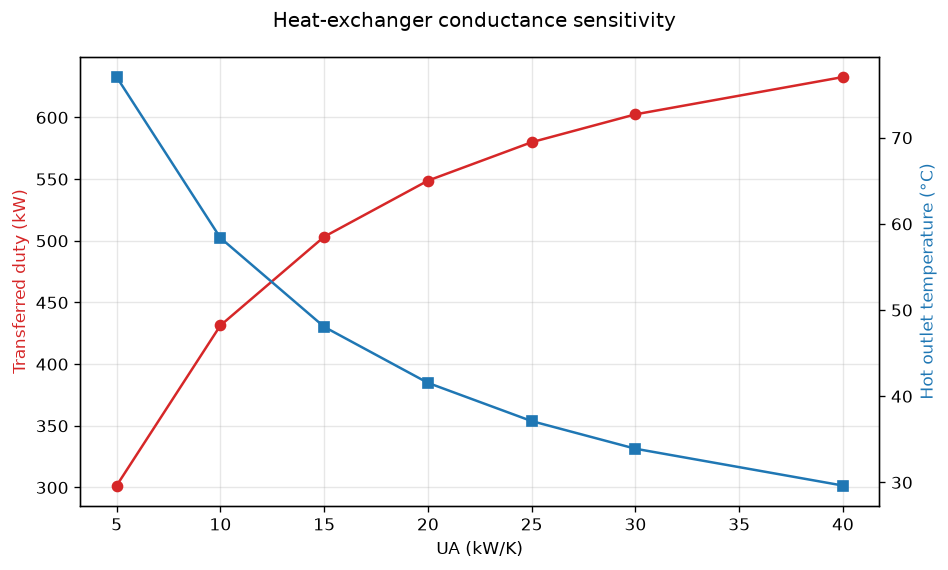

In [11]:
figure, first_axis = plt.subplots(figsize=(8.0, 4.8))
second_axis = first_axis.twinx()

first_axis.plot(
    ua_study["UA (kW/K)"],
    ua_study["Duty (kW)"],
    marker="o",
    color="tab:red",
    label="Transferred duty",
)
second_axis.plot(
    ua_study["UA (kW/K)"],
    ua_study["Hot outlet (°C)"],
    marker="s",
    color="tab:blue",
    label="Hot outlet",
)
first_axis.set_xlabel("UA (kW/K)")
first_axis.set_ylabel("Transferred duty (kW)", color="tab:red")
second_axis.set_ylabel("Hot outlet temperature (°C)", color="tab:blue")
first_axis.grid(alpha=0.3)
figure.suptitle("Heat-exchanger conductance sensitivity")
figure.tight_layout()

## Cold-side flow sensitivity

Changing flow changes both the heat-capacity-rate ratio and outlet temperatures. With fixed UA, increasing cold-side flow generally increases total duty but reduces the cold-stream temperature rise. This study recreates the whole process for every case.

In [12]:
cold_flow_values_kg_h = np.array([6_000.0, 8_000.0, 10_000.0, 12_000.0, 15_000.0, 18_000.0])
flow_rows = []

for cold_flow_kg_h in cold_flow_values_kg_h:
    case = run_exchanger_case(BASE_UA_W_K, cold_flow_kg_h)
    flow_rows.append(
        {
            "Cold flow (kg/h)": cold_flow_kg_h,
            "Duty (kW)": abs(case["duty_w"]) / 1_000.0,
            "Hot outlet (°C)": case["hot_outlet_c"],
            "Cold outlet (°C)": case["cold_outlet_c"],
            "Effectiveness": case["effectiveness"],
        }
    )

flow_study = pd.DataFrame(flow_rows)
print(flow_study.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

 Cold flow (kg/h)  Duty (kW)  Hot outlet (°C)  Cold outlet (°C)  Effectiveness
        6000.0000   400.3018          62.8426          116.3595         0.9630
        8000.0000   489.1809          50.0757          108.4232         0.8826
       10000.0000   545.1335          42.0715           98.9129         0.7868
       12000.0000   579.9359          37.1149           89.9971         0.8266
       15000.0000   610.6890          32.7534           78.9670         0.8704
       18000.0000   628.3468          30.2584           70.5309         0.8956


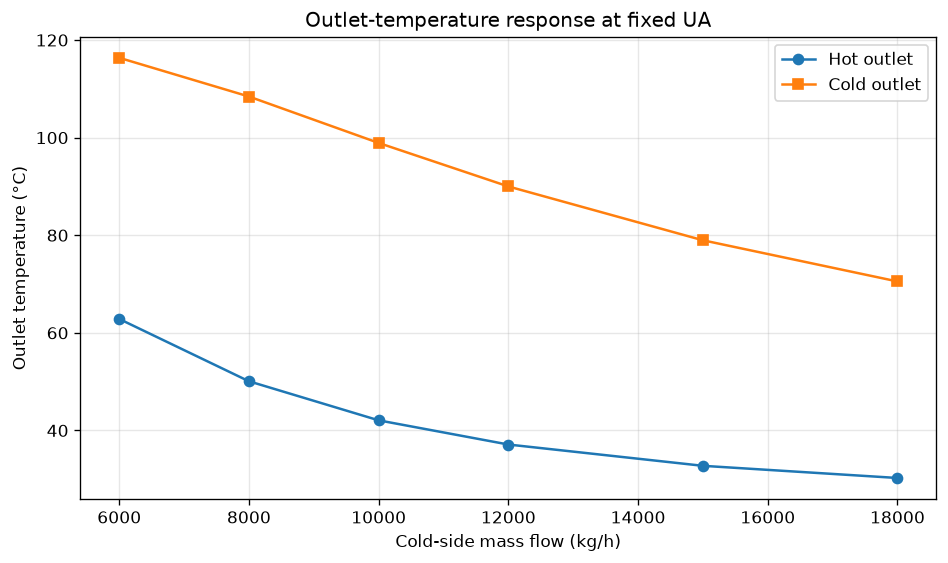

In [13]:
figure, axis = plt.subplots(figsize=(8.0, 4.8))
axis.plot(
    flow_study["Cold flow (kg/h)"],
    flow_study["Hot outlet (°C)"],
    marker="o",
    label="Hot outlet",
)
axis.plot(
    flow_study["Cold flow (kg/h)"],
    flow_study["Cold outlet (°C)"],
    marker="s",
    label="Cold outlet",
)
axis.set_xlabel("Cold-side mass flow (kg/h)")
axis.set_ylabel("Outlet temperature (°C)")
axis.set_title("Outlet-temperature response at fixed UA")
axis.grid(alpha=0.3)
axis.legend()
figure.tight_layout()

## Why property variation matters

Density affects velocity and pressure drop; viscosity and conductivity influence convective film coefficients; heat capacity controls the temperature change for a given duty. NeqSim supplies these properties consistently from the same flashed fluid state.

The grid below holds composition and pressure at 60 bara while changing temperature. The resulting trends are useful diagnostics, but a detailed exchanger rating would couple them to geometry-dependent correlations along the equipment.

In [14]:
property_temperatures_c = np.linspace(20.0, 120.0, 11)
property_grid_rows = []

for temperature_c in property_temperatures_c:
    gas = make_gas_system(temperature_c, 60.0)
    gas_phase = gas.getPhase("gas")
    property_grid_rows.append(
        {
            "Temperature (°C)": temperature_c,
            "Density (kg/m³)": gas_phase.getDensity("kg/m3"),
            "Cp (J/(kg K))": gas_phase.getCp("J/kgK"),
            "Viscosity (µPa s)": gas_phase.getViscosity("kg/msec") * 1.0e6,
            "Conductivity (W/(m K))": gas_phase.getThermalConductivity("W/mK"),
        }
    )

property_grid = pd.DataFrame(property_grid_rows)
print(property_grid.to_string(index=False, float_format=lambda value: f"{value:.6g}"))

 Temperature (°C)  Density (kg/m³)  Cp (J/(kg K))  Viscosity (µPa s)  Conductivity (W/(m K))
               20          52.3339        2592.02            12.6818               0.0386275
               30           49.593        2552.47            12.9154               0.0395662
               40          47.1977        2526.74            13.1575               0.0405752
               50          45.0782        2511.34            13.4057                0.041646
               60          43.1835        2503.92             13.658               0.0427722
               70          41.4752        2502.82            13.9132               0.0439487
               80          39.9237        2506.83            14.1701               0.0451717
               90           38.506        2515.06             14.428               0.0464379
              100          37.2034         2526.8            14.6864               0.0477447
              110          36.0009        2541.51            14.9448  

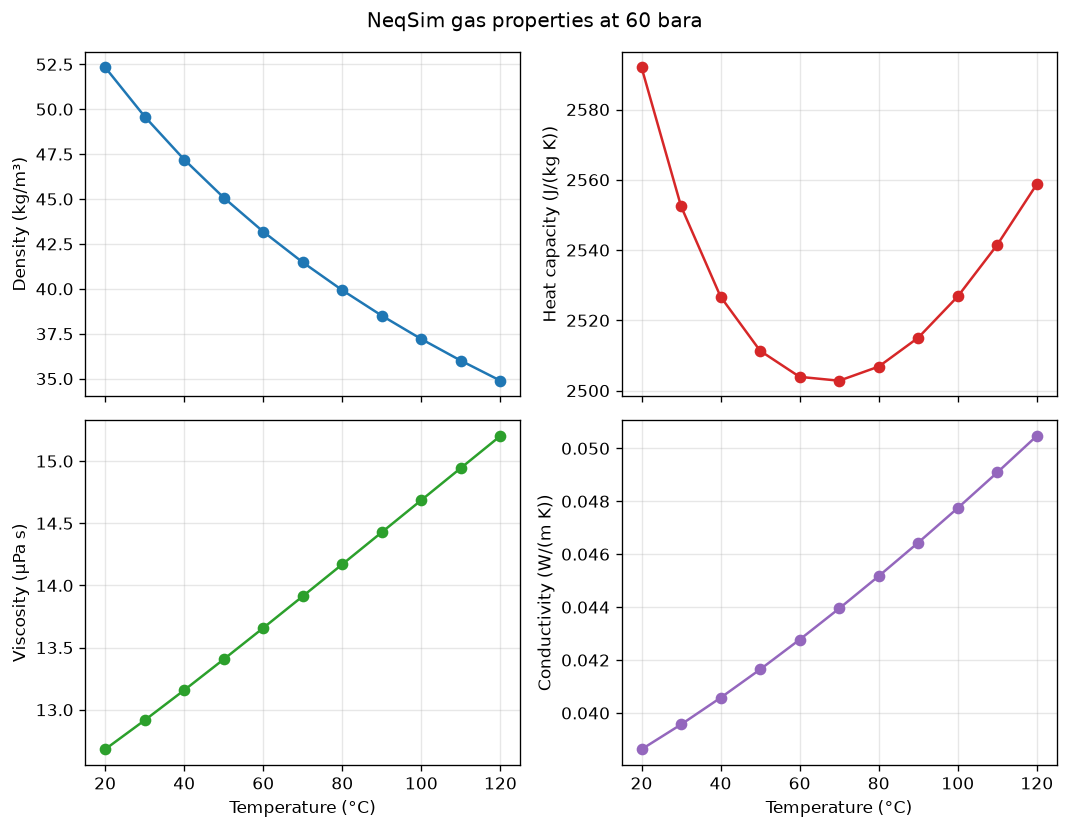

In [15]:
figure, axes = plt.subplots(2, 2, figsize=(9.0, 7.0), sharex=True)
properties_to_plot = [
    ("Density (kg/m³)", "Density (kg/m³)", "tab:blue"),
    ("Cp (J/(kg K))", "Heat capacity (J/(kg K))", "tab:red"),
    ("Viscosity (µPa s)", "Viscosity (µPa s)", "tab:green"),
    ("Conductivity (W/(m K))", "Conductivity (W/(m K))", "tab:purple"),
]

for axis, (column, label, color) in zip(axes.flat, properties_to_plot):
    axis.plot(
        property_grid["Temperature (°C)"],
        property_grid[column],
        marker="o",
        color=color,
    )
    axis.set_ylabel(label)
    axis.grid(alpha=0.3)

for axis in axes[-1, :]:
    axis.set_xlabel("Temperature (°C)")

figure.suptitle("NeqSim gas properties at 60 bara")
figure.tight_layout()

## Fouling scenario at fixed installed area

Fouling adds thermal resistance. For the installed area sized at the base fouled condition, a clean surface has higher UA, while an additional-deposit case has lower UA. The comparison uses the same NeqSim process model and changes only the resistance-derived conductance.

In [16]:
additional_deposit_resistance_m2_k_w = 0.0010
deposited_u_w_m2_k = 1.0 / (
    fouled_resistance_m2_k_w + additional_deposit_resistance_m2_k_w
)

condition_rows = []
for condition, overall_u_w_m2_k in [
    ("Clean", clean_u_w_m2_k),
    ("Design fouled", fouled_u_w_m2_k),
    ("Additional deposit", deposited_u_w_m2_k),
]:
    condition_ua_w_k = overall_u_w_m2_k * screening_area_m2
    case = run_exchanger_case(condition_ua_w_k)
    condition_rows.append(
        {
            "Condition": condition,
            "U (W/(m² K))": overall_u_w_m2_k,
            "UA (kW/K)": condition_ua_w_k / 1_000.0,
            "Duty (kW)": abs(case["duty_w"]) / 1_000.0,
            "Hot outlet (°C)": case["hot_outlet_c"],
        }
    )

fouling_study = pd.DataFrame(condition_rows)
print(fouling_study.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

         Condition  U (W/(m² K))  UA (kW/K)  Duty (kW)  Hot outlet (°C)
             Clean      132.9640    28.9889   598.4782          34.4828
     Design fouled      114.6679    25.0000   579.9359          37.1149
Additional deposit      102.8718    22.4282   565.2435          39.2049


## Validation strategy

The final checks require energy and mass closure, single-phase outlets, positive terminal approaches, effectiveness bounds, agreement with analytical methods, monotonic conductance and flow responses, finite properties, and the expected deterioration with fouling. These are engineering invariants rather than snapshots of every printed number.

In [17]:
checks = {
    "finite base results": all(
        np.isfinite(value)
        for value in [
            base_case["hot_outlet_c"],
            base_case["cold_outlet_c"],
            base_case["duty_w"],
            base_case["effectiveness"],
        ]
    ),
    "single-phase outlets": base_case["hot_phases"] == 1 and base_case["cold_phases"] == 1,
    "hot mass closure": abs(hot_mass_residual_kg_h) < 1.0e-6,
    "cold mass closure": abs(cold_mass_residual_kg_h) < 1.0e-6,
    "energy closure": abs(energy_residual_w) < 1.0e-3,
    "positive terminal approaches": terminal_difference_1_k > 0.0 and terminal_difference_2_k > 0.0,
    "bounded effectiveness": 0.0 < base_case["effectiveness"] < 1.0,
    "positive entropy generation": base_case["entropy_generation_w_k"] > 0.0,
    "effectiveness agreement": abs(effectiveness_difference) < 0.02,
    "LMTD agreement": abs(lmtd_relative_residual) < 0.05,
    "duty rises with UA": np.all(np.diff(ua_study["Duty (kW)"]) > 0.0),
    "hot outlet falls with UA": np.all(np.diff(ua_study["Hot outlet (°C)"]) < 0.0),
    "duty rises with cold flow": np.all(np.diff(flow_study["Duty (kW)"]) > 0.0),
    "density falls with temperature": np.all(np.diff(property_grid["Density (kg/m³)"]) < 0.0),
    "positive transport properties": (
        (property_grid["Viscosity (µPa s)"] > 0.0).all()
        and (property_grid["Conductivity (W/(m K))"] > 0.0).all()
    ),
    "additional fouling reduces duty": (
        fouling_study.iloc[2]["Duty (kW)"] < fouling_study.iloc[1]["Duty (kW)"]
    ),
}

failed_checks = [name for name, passed in checks.items() if not passed]
assert not failed_checks, f"Failed checks: {failed_checks}"

print(f"All {len(checks)} engineering checks passed.")
print(f"Energy residual: {energy_residual_w:.3e} W")
print(f"Base duty: {transferred_duty_w / 1_000.0:.3f} kW")
print(f"Screening area: {screening_area_m2:.3f} m²")

All 16 engineering checks passed.
Energy residual: 8.858e-05 W
Base duty: 579.936 kW
Screening area: 218.021 m²


## Interpretation, limitations, and applicability

The base duty and outlet temperatures are internally consistent with both an enthalpy balance and classical exchanger methods. The UA study shows diminishing returns as terminal temperature approaches shrink. The flow study demonstrates that outlet temperature is not a fixed equipment property: it depends on both capacity rates. The fouling case quantifies why thermal margin and cleaning strategy matter.

Apply this workflow to early screening, model integration, energy-recovery studies, and operating sensitivities. Do not use the assumed film coefficients for final sizing. Two-phase service, phase change, strong pressure drop, cross-flow, multi-pass correction factors, air coolers, plate exchangers, and reactive fluids need appropriate geometry and correlations. Validate the selected thermodynamic model against project fluid data when accuracy affects design decisions.

## Troubleshooting

- If an outlet contains more than one phase, stop using the single-phase effectiveness comparison and model phase change explicitly.
- If a terminal temperature difference is zero or negative, reduce UA, revise flow rates, or check stream orientation and specifications.
- If the process does not converge, verify positive flow rates, temperatures, pressures, and a plausible inlet phase before adding complexity.
- If a sensitivity trend is irregular, recreate the fluid and process for each point, as done here, and inspect phase count and solver warnings.
- If calculated area looks unrealistic, review the assumed film coefficients, fouling factors, flow regime, and exchanger type before changing NeqSim parameters.

## Summary, exercises, and references

This notebook connected NeqSim real-fluid properties to a composable two-stream exchanger and independently checked energy conservation, effectiveness–NTU, LMTD, resistance-derived area, operating sensitivities, and fouling response.

### Exercises

1. Replace the synthetic gas with a project composition and compare SRK with Peng–Robinson.
2. Add realistic pressure drops and quantify their effect on density and required area.
3. Replace the cold gas with a water or glycol utility using an appropriate thermodynamic model.
4. Fit film coefficients from a rated exchanger and test clean versus fouled operation.
5. Connect the outlet stream to a separator or compressor and quantify system-level energy savings.

### Authoritative references

- [NeqSim process simulation documentation](https://equinor.github.io/neqsim/process/README.html)
- [NeqSim heat-exchanger equipment documentation](https://equinor.github.io/neqsim/process/equipment/heat_exchangers)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [NeqSim thermodynamic model selection](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)

The analytical equations are standard steady-state heat-exchanger relations. They are used here as independent checks, not as replacements for project-specific design standards.